In [1]:
import pandas as pd
import os.path as op
import platform
import os
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin

In [2]:
if platform.system() == "Windows":
    wanted_dir = "/data/sourcedata/behavior/modified_files"
else:
    wanted_dir = "/Volumes/SDrive/data/sourcedata/behavior/modified_files"

files = [os.path.join(root, name) for root, dirs, files in os.walk(wanted_dir) for name in files if name.endswith('savedValues.csv')and not name.startswith("._")]

files.remove(files[7])
files.remove(files[11])
files.remove(files[13])
files.remove(files[38])
len(files)


58

In [12]:
subjects =[]
for i in range(len(files)):
    subjects.append(int(files[i][-18:-16]))
    
data_folder = '/Volumes/SDrive/data/'
subjects, len(subjects)

([1,
  2,
  3,
  4,
  5,
  6,
  7,
  9,
  10,
  11,
  12,
  14,
  15,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64],
 58)

In [13]:
df = []

for subject in subjects:
    d = pd.read_csv(op.join(data_folder, 'sourcedata', 'behavior', 'modified_files', f'modified_participant{subject:02d}_savedValues.csv'))

    df.append(d.set_index(['runNumber', 'trialNumber']))

df = pd.concat(df, keys=subjects, names=['subject'])

In [14]:
import os
import pandas as pd
import numpy as np
from scipy.io import loadmat  # Import loadmat if not already imported

spes = []
alpha = []

for subject in subjects:
    try:
        spe = loadmat(f'/Volumes/SDrive/data/fittedParameters/sub-{subject:02d}/spe.mat')['spe']

        spe = pd.DataFrame(spe, columns=pd.Index(np.arange(1, 61), name='trialNumber'), index=pd.Index(np.arange(1, 7), name='runNumber'))

        spe = spe.stack().to_frame('spe')

        spes.append(spe)

        alpha_dir = f'/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-{subject:02d}'

        # Find all files that start with "trialwise" and end with ".npy" in the subject directory
        alpha_files = [os.path.join(root, name) for root, dirs, files in os.walk(alpha_dir) for name in files if name.startswith("trialwise") and name.endswith(".npy")]
        
        # Load the numpy files into a list (alpha)
        alphas = [np.load(file) for file in alpha_files]

        alpha.extend(alphas)

    except Exception as e:
        subjects.remove(subject)  # Use remove instead of pop to remove subject from the list
        print(f'There was a problem with subject {subject}:\n{e}')

spes = pd.concat(spes, keys=subjects, names=['subject'])
spes

# You can access the alpha list for further processing
# Make sure to check if it's empty before using it.


spe
subject runNumber trialNumber          
1       1         1            2.197225
                  2            2.302585
                  3            2.397895
                  4            2.484907
                  5            2.564949
...                                 ...
64      6         56           3.060271
                  57           1.871802
                  58           2.397895
                  59           2.258782
                  60           2.273598

[20880 rows x 1 columns]

In [6]:
alpha

[array([[0.99345437, 0.93624604, 0.98699443, 0.88062121, 0.98061906,
         0.97432715, 0.83208899, 0.96811761, 0.96198936, 0.9496044 ,
         0.78974501, 0.94371851, 0.93161285, 0.9259625 , 0.75280022,
         0.92656334, 0.92097909, 0.92107925, 0.66087679, 0.90910629,
         0.58731475, 0.89721546, 0.51684526, 0.89854403, 0.45855426,
         0.88678869, 0.88775353, 0.87613259, 0.52347201, 0.87762731,
         0.86618091, 0.86776473, 0.8564047 , 0.58209863, 0.85695808,
         0.84669886, 0.83702589, 0.82606818, 0.50925483, 0.82834409,
         0.44499724, 0.81750003, 0.80702794, 0.79870993, 0.7882982 ,
         0.77843069, 0.76824578, 0.38863199, 0.75818848,        nan,
         0.35483829, 0.74840992, 0.74019878, 0.36839098, 0.74191704,
                nan, 0.74235136, 0.3965324 , 0.73434195, 0.39130036],
        [0.57097044, 0.99828164, 0.51007361, 0.50142986, 0.50020296,
         0.50002881, 0.28540223, 0.68466804, 0.99656918, 0.99486261,
         0.99316191, 0.99318245, 

In [6]:
df = df.join(spes)

In [7]:
list(df.columns)

['visualSet',
 'audioPair_1',
 'audioPair_2',
 'audioPair_3',
 'tactilePair_1',
 'tactilePair_2',
 'tactilePair_3',
 'visual',
 'audio',
 'tactile',
 'combinationConditionalProbability',
 'correctResponse',
 'chosenKey',
 'accurate',
 'reward',
 'runStartTime',
 'trialStartTime',
 'stimulusOnsetTime',
 'stimulusOffsetTime',
 'responsePressTime',
 'responseTime',
 'responseTimeOver',
 'feedbackOnsetTime',
 'responseTimeThreshold',
 'totalAccuracy',
 'totalErrorRate',
 'accurateIndex',
 'inaccurateIndex',
 'feedbackAccuracy',
 'feedbackOffsetTime',
 'action',
 'stimulusPair',
 'spe']

0.06448031642506036


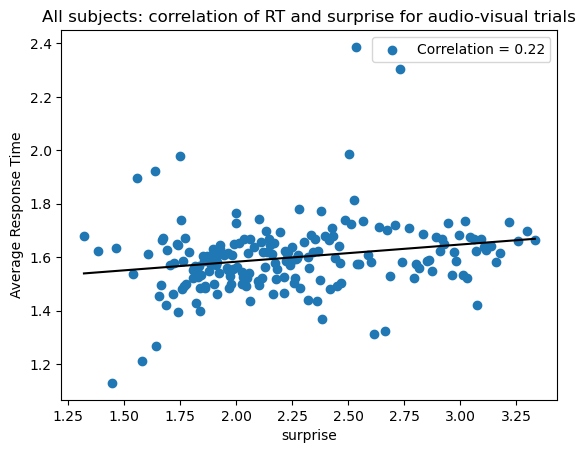

In [8]:

audio_df = df.dropna(subset=['audio'])


avg_response_time = audio_df.groupby('spe')['responseTime'].mean()

plt.scatter(avg_response_time.index, avg_response_time.values, label=f'Correlation = {np.round(np.corrcoef(avg_response_time.index, avg_response_time.values)[0,1], 2)}')

plt.legend()

m, b = np.polyfit(avg_response_time.index, avg_response_time.values, 1)
plt.plot(avg_response_time.index, m*avg_response_time.index+b, c = "k")


print(m)

plt.xlabel('surprise')
plt.ylabel('Average Response Time')
plt.title("All subjects: correlation of RT and surprise for audio-visual trials")
plt.show()

In [9]:
df

visualSet  audioPair_1  audioPair_2  \
subject runNumber trialNumber                                        
1       1         1                    0            1            0   
                  2                    0            1            0   
                  3                    0            1            0   
                  4                    0            1            0   
                  5                    0            1            0   
...                                  ...          ...          ...   
64      6         56                   5            2            0   
                  57                   5            2            0   
                  58                   5            2            0   
                  59                   5            2            0   
                  60                   5            2            0   

                               audioPair_3  tactilePair_1  tactilePair_2  \
subject runNumber trialNumber                                              
1       1         1                      2              0              1   
                  2                      2              0              1   
                  3                      2              0              1   
                  4                      2              0              1   
                  5                      2              0              1   
...                                    ...            ...            ...   
64      6         56                     1              1              2   
                  57                     1              1              2   
                  58                     1              1              2   
                  59                     1              1              2   
                  60                     1              1              2   

                               tactilePair_3  visual  audio  tactile  ...  \
subject runNumber trialNumber                                         ...   
1       1         1                        2       0    NaN      2.0  ...   
                  2                        2       1    NaN      1.0  ...   
                  3                        2       2    NaN      2.0  ...   
                  4                        2       0    NaN      0.0  ...   
                  5                        2       2    NaN      1.0  ...   
...                                      ...     ...    ...      ...  ...   
64      6         56                       0       0    1.0      NaN  ...   
                  57                       0       1    0.0      NaN  ...   
                  58                       0       2    2.0      NaN  ...   
                  59                       0       1    1.0      NaN  ...   
                  60                       0       2    2.0      NaN  ...   

                               responseTimeThreshold  totalAccuracy  \
subject runNumber trialNumber                                         
1       1         1                                3       0.000000   
                  2                                3       0.000000   
                  3                                3       0.333333   
                  4                                3       0.250000   
                  5                                3       0.200000   
...                                              ...            ...   
64      6         56                               3       0.892857   
                  57                               3       0.894737   
                  58                               3       0.896552   
                  59                               3       0.898305   
                  60                               3       0.900000   

                              totalErrorRate  accurateIndex  inaccurateIndex  \
subject runNumber trialNumber                                                  
1       1         1                 1.000000 

In [10]:
pingouin.rm_corr(audio_df.reset_index(), x='spe', y='responseTime', subject='subject')

,r,dof,pval,CI95%,power
rm_corr,0.079453,10303,6.619029e-16,"[0.06, 0.1]",1.0


0.02815367410674916


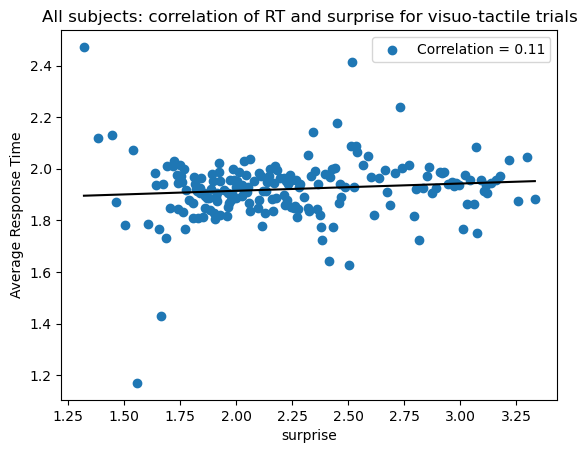

In [11]:

tactile_df = df.dropna(subset=['tactile'])


avg_response_time = tactile_df.groupby('spe')['responseTime'].mean()

plt.scatter(avg_response_time.index, avg_response_time.values, label=f'Correlation = {np.round(np.corrcoef(avg_response_time.index, avg_response_time.values)[0,1], 2)}')

plt.legend()

m, b = np.polyfit(avg_response_time.index, avg_response_time.values, 1)
plt.plot(avg_response_time.index, m*avg_response_time.index+b, c = "k")

print(m) 

plt.xlabel('surprise')
plt.ylabel('Average Response Time')
plt.title("All subjects: correlation of RT and surprise for visuo-tactile trials")
plt.show()

In [17]:
pingouin.rm_corr(tactile_df.reset_index(), x='spe', y='responseTime', subject='subject')

,r,dof,pval,CI95%,power
rm_corr,0.038062,10264,0.000115,"[0.02, 0.06]",0.971154


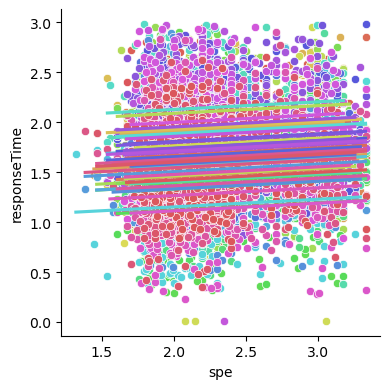

In [18]:
pingouin.plot_rm_corr(audio_df.reset_index(), x='spe', y='responseTime', subject='subject')

Text(-11.055555555555555, 0.5, 'r')

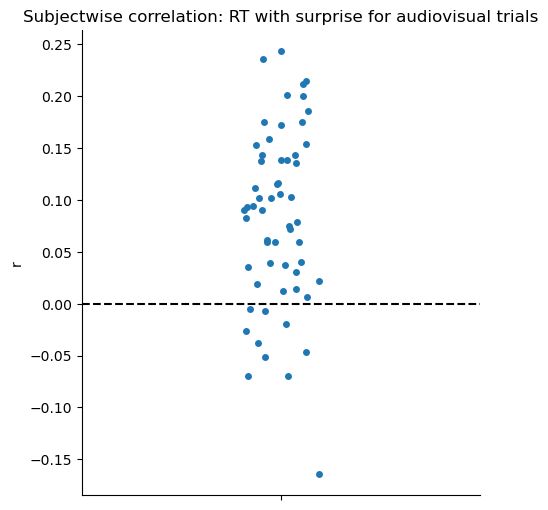

In [19]:

r_a = audio_df.groupby('subject').apply(lambda d: pingouin.corr(d['spe'], d['responseTime']))

sns.catplot(r_a, y='r')
plt.axhline(0.0, c='k' ,ls='--')
plt.title("Subjectwise correlation: RT with surprise for audiovisual trials")
plt.ylabel("r")

Text(0.5, 1.0, 'Subjectwise correlation: RT with surprise for visuotactile trials')

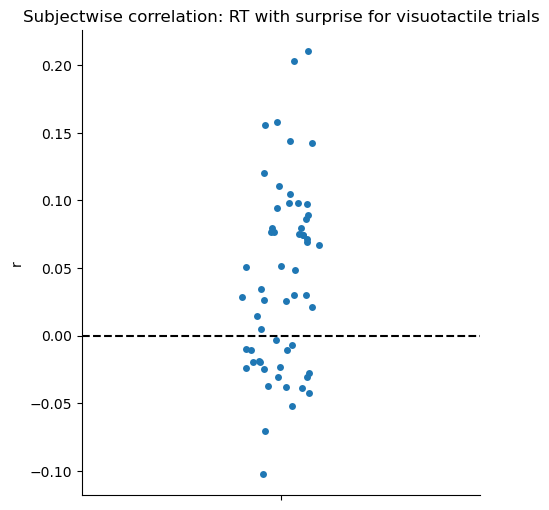

In [20]:

r_t = tactile_df.groupby('subject').apply(lambda d: pingouin.corr(d['spe'], d['responseTime']))

sns.catplot(r_t, y='r')
plt.axhline(0.0, c='k' ,ls='--')
plt.title("Subjectwise correlation: RT with surprise for visuotactile trials")

In [21]:
df['audio_indicator'] = df['audio'].notna().astype(int)
df

visualSet  audioPair_1  audioPair_2  \
subject runNumber trialNumber                                        
1       1         1                    0            1            0   
                  2                    0            1            0   
                  3                    0            1            0   
                  4                    0            1            0   
                  5                    0            1            0   
...                                  ...          ...          ...   
64      6         56                   5            2            0   
                  57                   5            2            0   
                  58                   5            2            0   
                  59                   5            2            0   
                  60                   5            2            0   

                               audioPair_3  tactilePair_1  tactilePair_2  \
subject runNumber trialNumber                                              
1       1         1                      2              0              1   
                  2                      2              0              1   
                  3                      2              0              1   
                  4                      2              0              1   
                  5                      2              0              1   
...                                    ...            ...            ...   
64      6         56                     1              1              2   
                  57                     1              1              2   
                  58                     1              1              2   
                  59                     1              1              2   
                  60                     1              1              2   

                               tactilePair_3  visual  audio  tactile  ...  \
subject runNumber trialNumber                                         ...   
1       1         1                        2       0    NaN      2.0  ...   
                  2                        2       1    NaN      1.0  ...   
                  3                        2       2    NaN      2.0  ...   
                  4                        2       0    NaN      0.0  ...   
                  5                        2       2    NaN      1.0  ...   
...                                      ...     ...    ...      ...  ...   
64      6         56                       0       0    1.0      NaN  ...   
                  57                       0       1    0.0      NaN  ...   
                  58                       0       2    2.0      NaN  ...   
                  59                       0       1    1.0      NaN  ...   
                  60                       0       2    2.0      NaN  ...   

                               totalAccuracy  totalErrorRate accurateIndex  \
subject runNumber trialNumber                                                
1       1         1                 0.000000        1.000000             1   
                  2                 0.000000        1.000000             1   
                  3                 0.333333        0.666667             1   
                  4                 0.250000        0.750000             2   
                  5                 0.200000        0.800000             2   
...                                      ...             ...           ...   
64      6         56                0.892857        0.107143            50   
                  57                0.894737        0.105263            51   
                  58                0.896552        0.103448            52   
                  59                0.898305        0.101695            53   
                  60                0.900000        0.100000            54   

                               inaccurateIndex  feedbackAccuracy  \
subject runNumber trialNumber                 

In [22]:
df['responseTime'].isnull().sum()

195

In [23]:
runWiseDF = df.groupby(['subject', 'runNumber']).apply(lambda x: x['spe'].corr(x['responseTime'])).reset_index()
runWiseDF.columns = ['subject', 'runNumber', 'surpriseEffect']
last_total_accuracy_df = df.groupby(['subject', 'runNumber'])['totalAccuracy'].last().reset_index()
last_total_accuracy_df.columns = ['subject', 'runNumber', 'lastTotalAccuracy']

# Merge the last totalAccuracy values into runWiseDF
runWiseDF = runWiseDF.merge(last_total_accuracy_df, on=['subject', 'runNumber'])

audio_indicator_df = df.groupby(['subject', 'runNumber'])['audio_indicator'].first().reset_index()
audio_indicator_df.columns = ['subject', 'runNumber', 'audio_indicator']

# Merge the audio_indicator values into runWiseDF
runWiseDF = runWiseDF.merge(audio_indicator_df, on=['subject', 'runNumber'])

print(runWiseDF)


     subject  runNumber  surpriseEffect  lastTotalAccuracy  audio_indicator
0          1          1       -0.225921           0.431034                0
1          1          2        0.198669           0.550000                1
2          1          3        0.346926           0.728814                0
3          1          4       -0.002973           0.833333                1
4          1          5       -0.022039           0.750000                0
..       ...        ...             ...                ...              ...
343       64          2        0.034180           0.933333                1
344       64          3       -0.059898           0.847458                0
345       64          4       -0.223336           0.750000                1
346       64          5        0.086630           0.666667                0
347       64          6        0.167114           0.900000                1

[348 rows x 5 columns]


In [24]:
subjectWiseDF = runWiseDF.groupby(['subject', 'audio_indicator']).agg({
    'surpriseEffect': 'mean',
    'lastTotalAccuracy': 'mean'
}).reset_index()

# Rename columns if needed
subjectWiseDF.columns = ['subject', 'audio_indicator', 'meanSurpriseEffect', 'meanLastTotalAccuracy']

print(subjectWiseDF)

     subject  audio_indicator  meanSurpriseEffect  meanLastTotalAccuracy
0          1                0            0.032988               0.636616
1          1                1            0.082193               0.748467
2          2                0           -0.026722               0.713653
3          2                1            0.131631               0.910923
4          3                0           -0.015970               0.655556
..       ...              ...                 ...                    ...
111       62                1           -0.071982               0.441431
112       63                0           -0.009903               0.451446
113       63                1            0.063998               0.477778
114       64                0            0.084163               0.748756
115       64                1           -0.007347               0.861111

[116 rows x 4 columns]


In [79]:

from scipy.stats import pearsonr

# Create a dictionary to store correlations and p-values
correlation_data = {
}

# Create subsets based on audio_indicator
rl_av = subjectWiseDF[subjectWiseDF['audio_indicator'] == 1]['meanLastTotalAccuracy']
rl_tv = subjectWiseDF[subjectWiseDF['audio_indicator'] == 0]['meanLastTotalAccuracy']
sl_av = subjectWiseDF[subjectWiseDF['audio_indicator'] == 1]['meanSurpriseEffect']
sl_tv = subjectWiseDF[subjectWiseDF['audio_indicator'] == 0]['meanSurpriseEffect']

# Calculate correlations and p-values
correlation_data["RLAV_RLTV"], p_value_rlav_rltv = pearsonr(rl_av, rl_tv)
correlation_data["RLAV_SLAV"], p_value_rlav_slav = pearsonr(rl_av, sl_av)
correlation_data["RLAV_SLTV"], p_value_rlav_sltv = pearsonr(rl_av, sl_tv)
correlation_data["RLTV_SLAV"], p_value_rltv_slav = pearsonr(rl_tv, sl_av)
correlation_data["RLTV_SLTV"], p_value_rltv_sltv = pearsonr(rl_tv, sl_tv)
correlation_data["SLAV_SLTV"], p_value_slav_sltv = pearsonr(sl_av, sl_tv)

# Create an empty correlation matrix
correlation_matrix = pd.DataFrame(index=['RLAV', 'RLTV', 'SLAV', 'SLTV'], columns=['RLAV', 'RLTV', 'SLAV', 'SLTV'])

# Fill the diagonal elements with 1
correlation_matrix.values[[range(4)], [range(4)]] = 1

# Fill the lower and upper triangular parts with the provided correlations and add significance stars
for i, row_label in enumerate(correlation_matrix.index):
    for j, col_label in enumerate(correlation_matrix.columns):
        if i < j:
            correlation_value = correlation_data.get(f'{row_label}_{col_label}', None)
            p_value = globals()[f'p_value_{row_label.lower()}_{col_label.lower()}']
            if p_value <= 0.01:
                correlation_matrix.loc[row_label, col_label] = f"{correlation_value:.2f}***"
            elif p_value <= 0.05:
                correlation_matrix.loc[row_label, col_label] = f"{correlation_value:.2f}**"
            elif p_value <= 0.1:
                correlation_matrix.loc[row_label, col_label] = f"{correlation_value:.2f}*"
            else:
                correlation_matrix.loc[row_label, col_label] = f"{correlation_value:.2f}"
        else:
            correlation_matrix.loc[row_label, col_label] = correlation_matrix.loc[col_label, row_label]

print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
         RLAV     RLTV     SLAV     SLTV
RLAV        1  0.82***  0.41***  0.42***
RLTV  0.82***        1  0.37***  0.49***
SLAV  0.41***  0.37***        1     0.19
SLTV  0.42***  0.49***     0.19        1


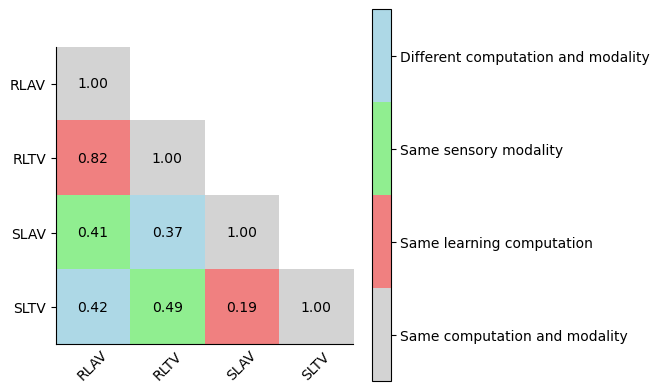

In [149]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define the correlation matrix values as numbers (remove stars)
correlation_matrix = np.array([
    [1, 0.82, 0.41, 0.42],
    [0.82, 1, 0.37, 0.49],
    [0.41, 0.37, 1, 0.19],
    [0.42, 0.49, 0.19, 1]
])

# Define row and column labels
row_labels = ['RLAV', 'RLTV', 'SLAV', 'SLTV']
col_labels = ['RLAV', 'RLTV', 'SLAV', 'SLTV']

# Create custom colormap with lighter colors
cmap = ListedColormap(['lightgray', 'lightcoral', 'lightgreen', 'lightblue'])

# Create an empty image matrix
image_matrix = np.zeros_like(correlation_matrix, dtype=float)

# Define color codes based on row and column names
for i, row_label in enumerate(row_labels):
    for j, col_label in enumerate(col_labels):
        if i >= j:
            if row_label == col_label:
                image_matrix[i, j] = 0  # grey for diagonal (both parts same)
            elif row_label[:2] == col_label[:2]:
                image_matrix[i, j] = 1  # Red for same first two letters
            elif row_label[-2:] == col_label[-2:]:
                image_matrix[i, j] = 2  # Green for same last two letters
            else:
                image_matrix[i, j] = 3  # Blue for different parts
        else:
            image_matrix[i, j] = np.nan  # Set to NaN for upper right triangle

# Create the heatmap using the custom colormap
plt.matshow(image_matrix, cmap=cmap, vmin=-0.5, vmax=3.5)  # Adjust vmin and vmax for color limits

# Remove top and right axis lines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Remove tick marks on the upper x-axis
plt.tick_params(axis='x', which='both', bottom=False, top=False)

# Set labels for the axes with column names at the bottom
plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha='center', position=(0,-0.16))
plt.yticks(range(len(row_labels)), row_labels)

# Display correlation values inside the cells
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        if i >= j:
            plt.text(j, i, f'{correlation_matrix[i, j]:.2f}', ha='center', va='center')

# Show the color bar with legend
cbar = plt.colorbar(ticks=[0, 1, 2, 3], boundaries=np.arange(-0.5, 4.5))
cbar.set_ticklabels(['Same computation and modality', 'Same learning computation', 'Same sensory modality', 'Different computation and modality'])

# Display the plot
plt.show()


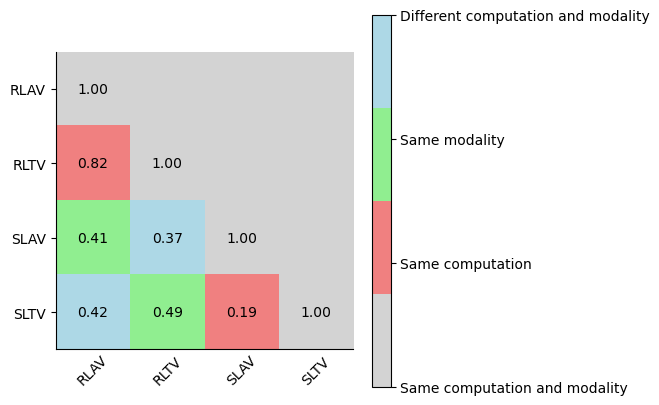

In [144]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define the correlation matrix values as numbers (remove stars)
correlation_matrix = np.array([
    [1, 0.82, 0.41, 0.42],
    [0.82, 1, 0.37, 0.49],
    [0.41, 0.37, 1, 0.19],
    [0.42, 0.49, 0.19, 1]
])

# Define row and column labels
row_labels = ['RLAV', 'RLTV', 'SLAV', 'SLTV']
col_labels = ['RLAV', 'RLTV', 'SLAV', 'SLTV']

# Create custom colormap with lighter colors
cmap = ListedColormap(['lightgray', 'lightcoral', 'lightgreen', 'lightblue'])

# Create an empty image matrix
image_matrix = np.zeros_like(correlation_matrix, dtype=float)

# Define color codes based on row and column names
for i, row_label in enumerate(row_labels):
    for j, col_label in enumerate(col_labels):
        if i >= j:
            if row_label == col_label:
                image_matrix[i, j] = 0  # grey for diagonal (both parts same)
            elif row_label[:2] == col_label[:2]:
                image_matrix[i, j] = 1  # Red for same first two letters
            elif row_label[-2:] == col_label[-2:]:
                image_matrix[i, j] = 2  # Green for same last two letters
            else:
                image_matrix[i, j] = 3  # Blue for different parts
        else:
            image_matrix[i, j] = 4

# Set the upper right triangle to white (anything above the diagonal)
image_matrix[np.triu_indices(len(image_matrix), k=1)] = 0.0

# Create the heatmap using the custom colormap
plt.matshow(image_matrix, cmap=cmap)

# Remove top and right axis lines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Remove tick marks on the upper x-axis
plt.tick_params(axis='x', which='both', bottom=False, top=False)

# Set labels for the axes with column names at the bottom
plt.xticks(range(len(col_labels)), col_labels, rotation=45, ha='center', position=(0,-0.16))
plt.yticks(range(len(row_labels)), row_labels)

# Display correlation values inside the cells
for i in range(len(row_labels)):
    for j in range(len(col_labels)):
        if i >= j:
            plt.text(j, i, f'{correlation_matrix[i, j]:.2f}', ha='center', va='center')

# Show the color bar with legend
cbar = plt.colorbar(ticks=[0, 1, 2, 3])
cbar.set_ticklabels(['Same computation and modality', 'Same computation', 'Same modality', 'Different computation and modality'])

# Display the plot
plt.show()


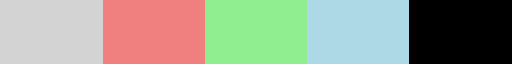

In [141]:
ListedColormap(['lightgray', 'lightcoral', 'lightgreen', 'lightblue','black'])

In [106]:
correlation_matrix

array([[1.  , 0.82, 0.41, 0.42],
       [0.82, 1.  , 0.37, 0.49],
       [0.41, 0.37, 1.  , 0.19],
       [0.42, 0.49, 0.19, 1.  ]])

In [50]:
correlation_matrix[1, 1]:.2f

SyntaxError: invalid syntax (3124832111.py, line 1)

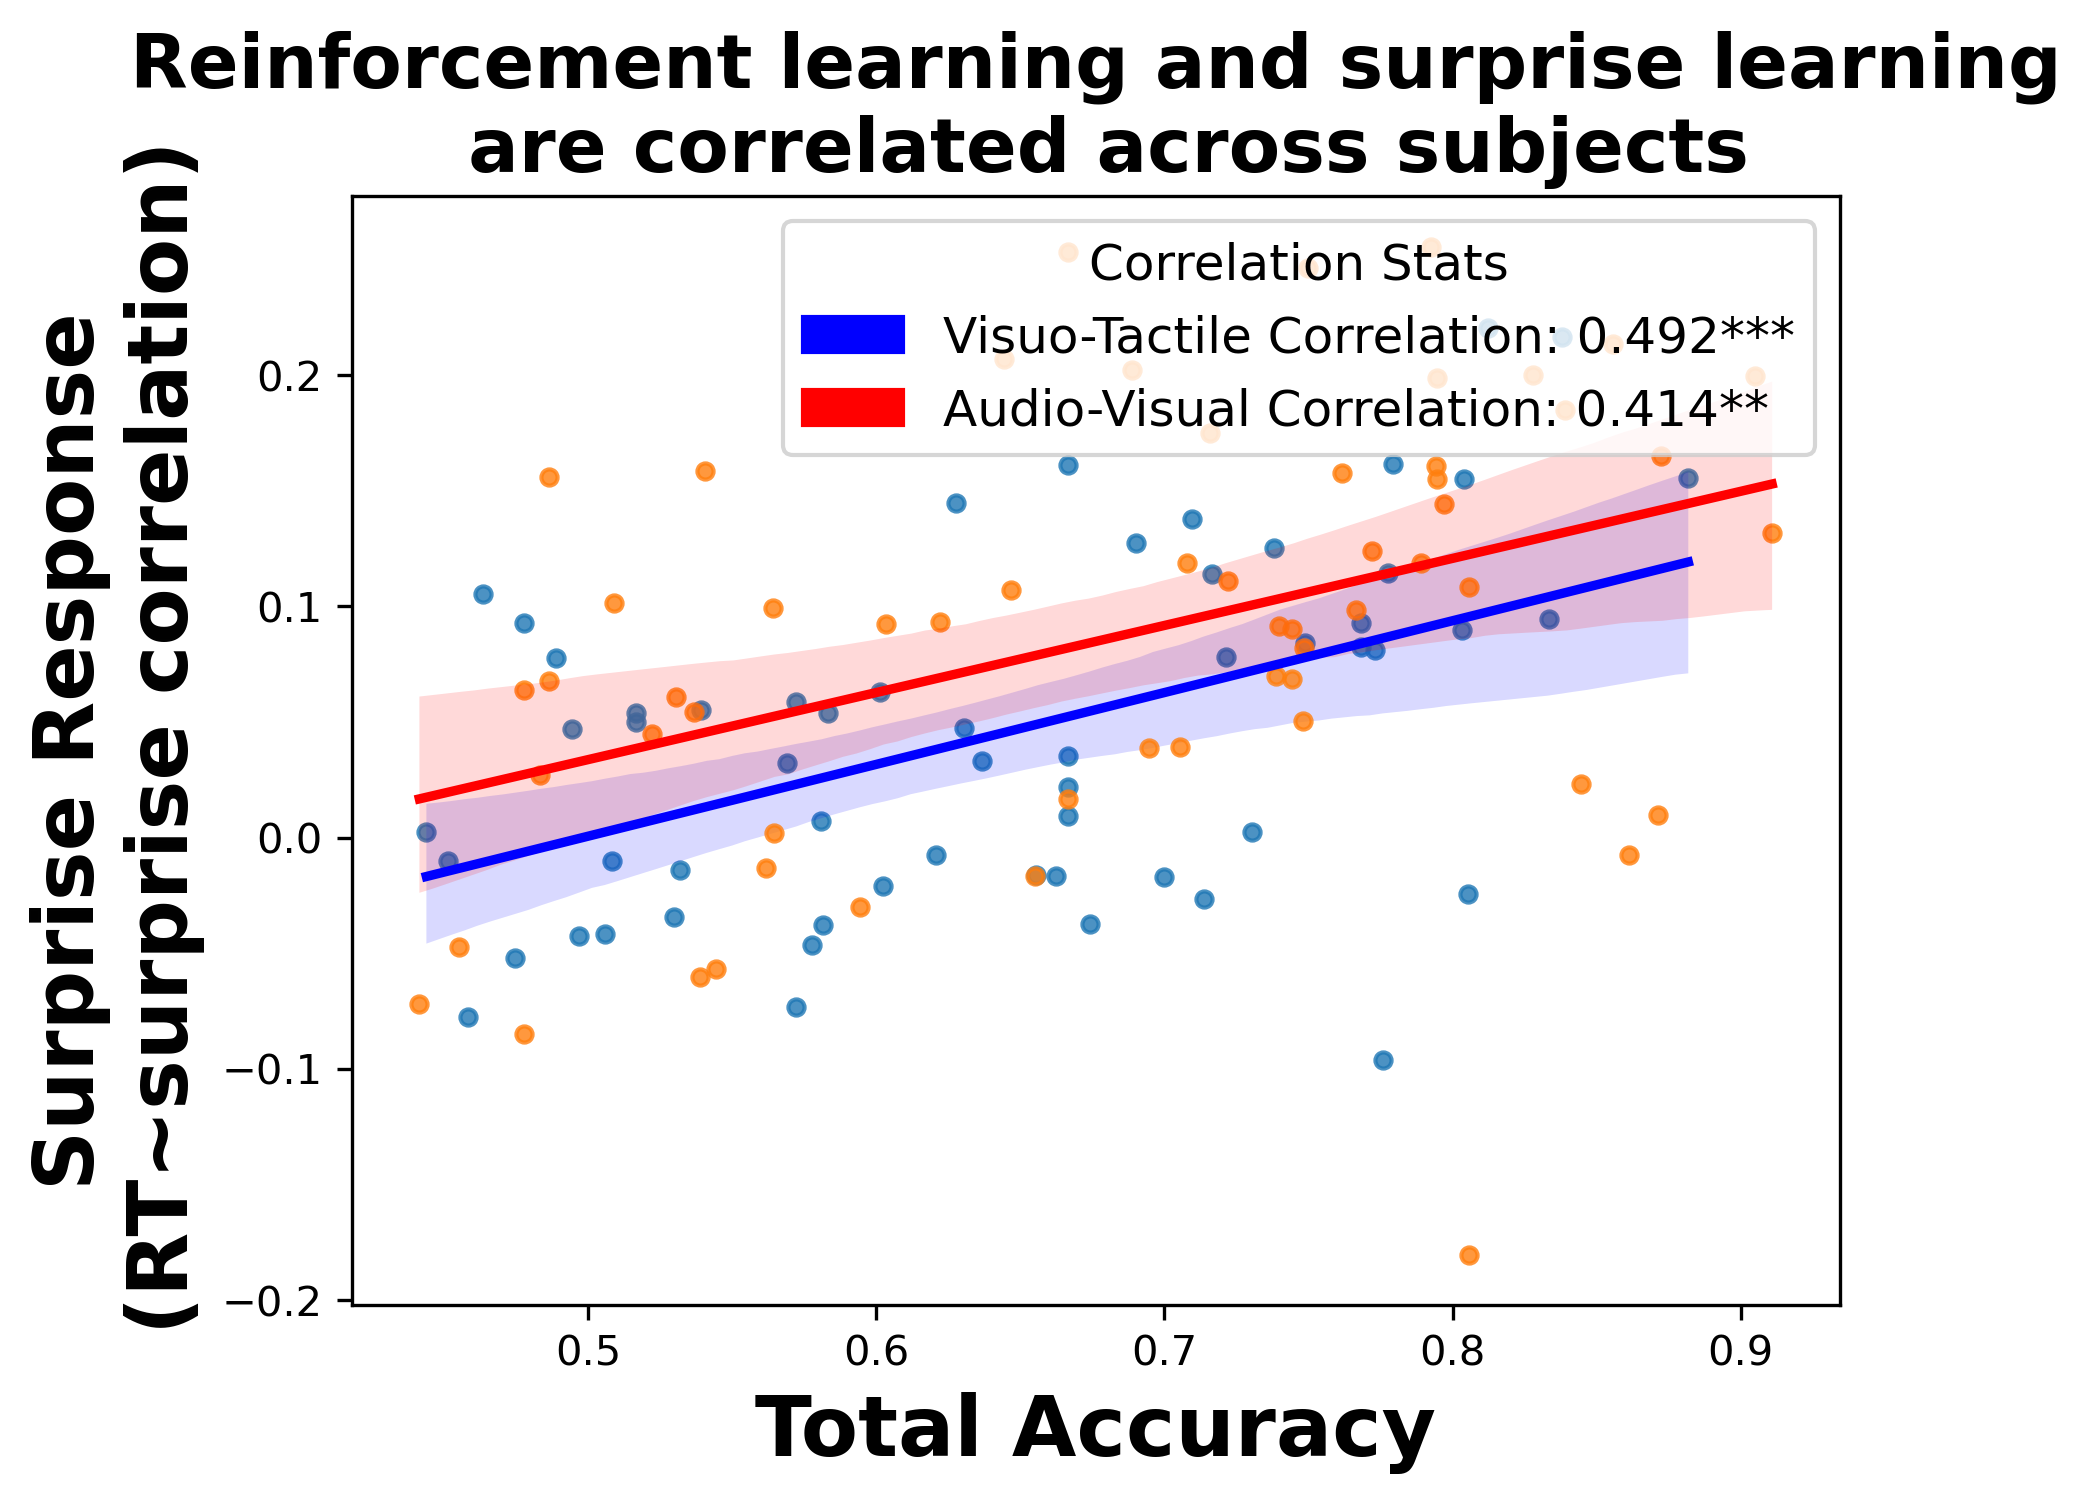

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.patches as mpatches

# Set a high DPI for high-quality images
plt.rcParams['figure.dpi'] = 300
# Create separate dataframes for audio_indicator 0 and 1 in subjectWiseDF
df_audio_0 = subjectWiseDF[subjectWiseDF['audio_indicator'] == 0]
df_audio_1 = subjectWiseDF[subjectWiseDF['audio_indicator'] == 1]

# Create a scatterplot with regression line for audio_indicator = 0 (blue)
sns.regplot(data=df_audio_0, x='meanLastTotalAccuracy', y='meanSurpriseEffect', line_kws={"color": "blue"}, scatter_kws={"s": 15})

# Create a scatterplot with regression line for audio_indicator = 1 (red)
sns.regplot(data=df_audio_1, x='meanLastTotalAccuracy', y='meanSurpriseEffect', line_kws={"color": "red"}, scatter_kws={"s": 15})

# Calculate the correlation and p-value for audio_indicator = 0
correlation_tactile, p_value_tactile = stats.pearsonr(df_audio_0['meanLastTotalAccuracy'], df_audio_0['meanSurpriseEffect'])

# Calculate the correlation and p-value for audio_indicator = 1
correlation_audio, p_value_audio = stats.pearsonr(df_audio_1['meanLastTotalAccuracy'], df_audio_1['meanSurpriseEffect'])

# Set plot labels
plt.xlabel('Total Accuracy', fontsize=20, weight='bold')
plt.ylabel('Surprise Response\n (RT~surprise correlation)', fontsize=20, weight='bold')

# Create custom legend with stars for significance
legend_labels = [
    mpatches.Patch(color='blue', label=f'Visuo-Tactile Correlation: {correlation_tactile:.3f}***' if p_value_tactile < 0.001 else f'Visuo-Tactile Correlation: {correlation_tactile:.3f}'),
    mpatches.Patch(color='red', label=f'Audio-Visual Correlation: {correlation_audio:.3f}***' if p_value_audio < 0.001 else (f'Audio-Visual Correlation: {correlation_audio:.3f}**' if p_value_audio < 0.01 else f'Audio-Visual Correlation: {correlation_audio:.3f}*'))
]

# Add legend with custom text labels and line colors
plt.legend(handles=legend_labels, loc='upper right', fontsize=12, title='Correlation Stats', title_fontsize=12)

# Set the title
plt.title('Reinforcement learning and surprise learning\n are correlated across subjects', fontsize=18, weight='bold')

# Show the plot
plt.show()


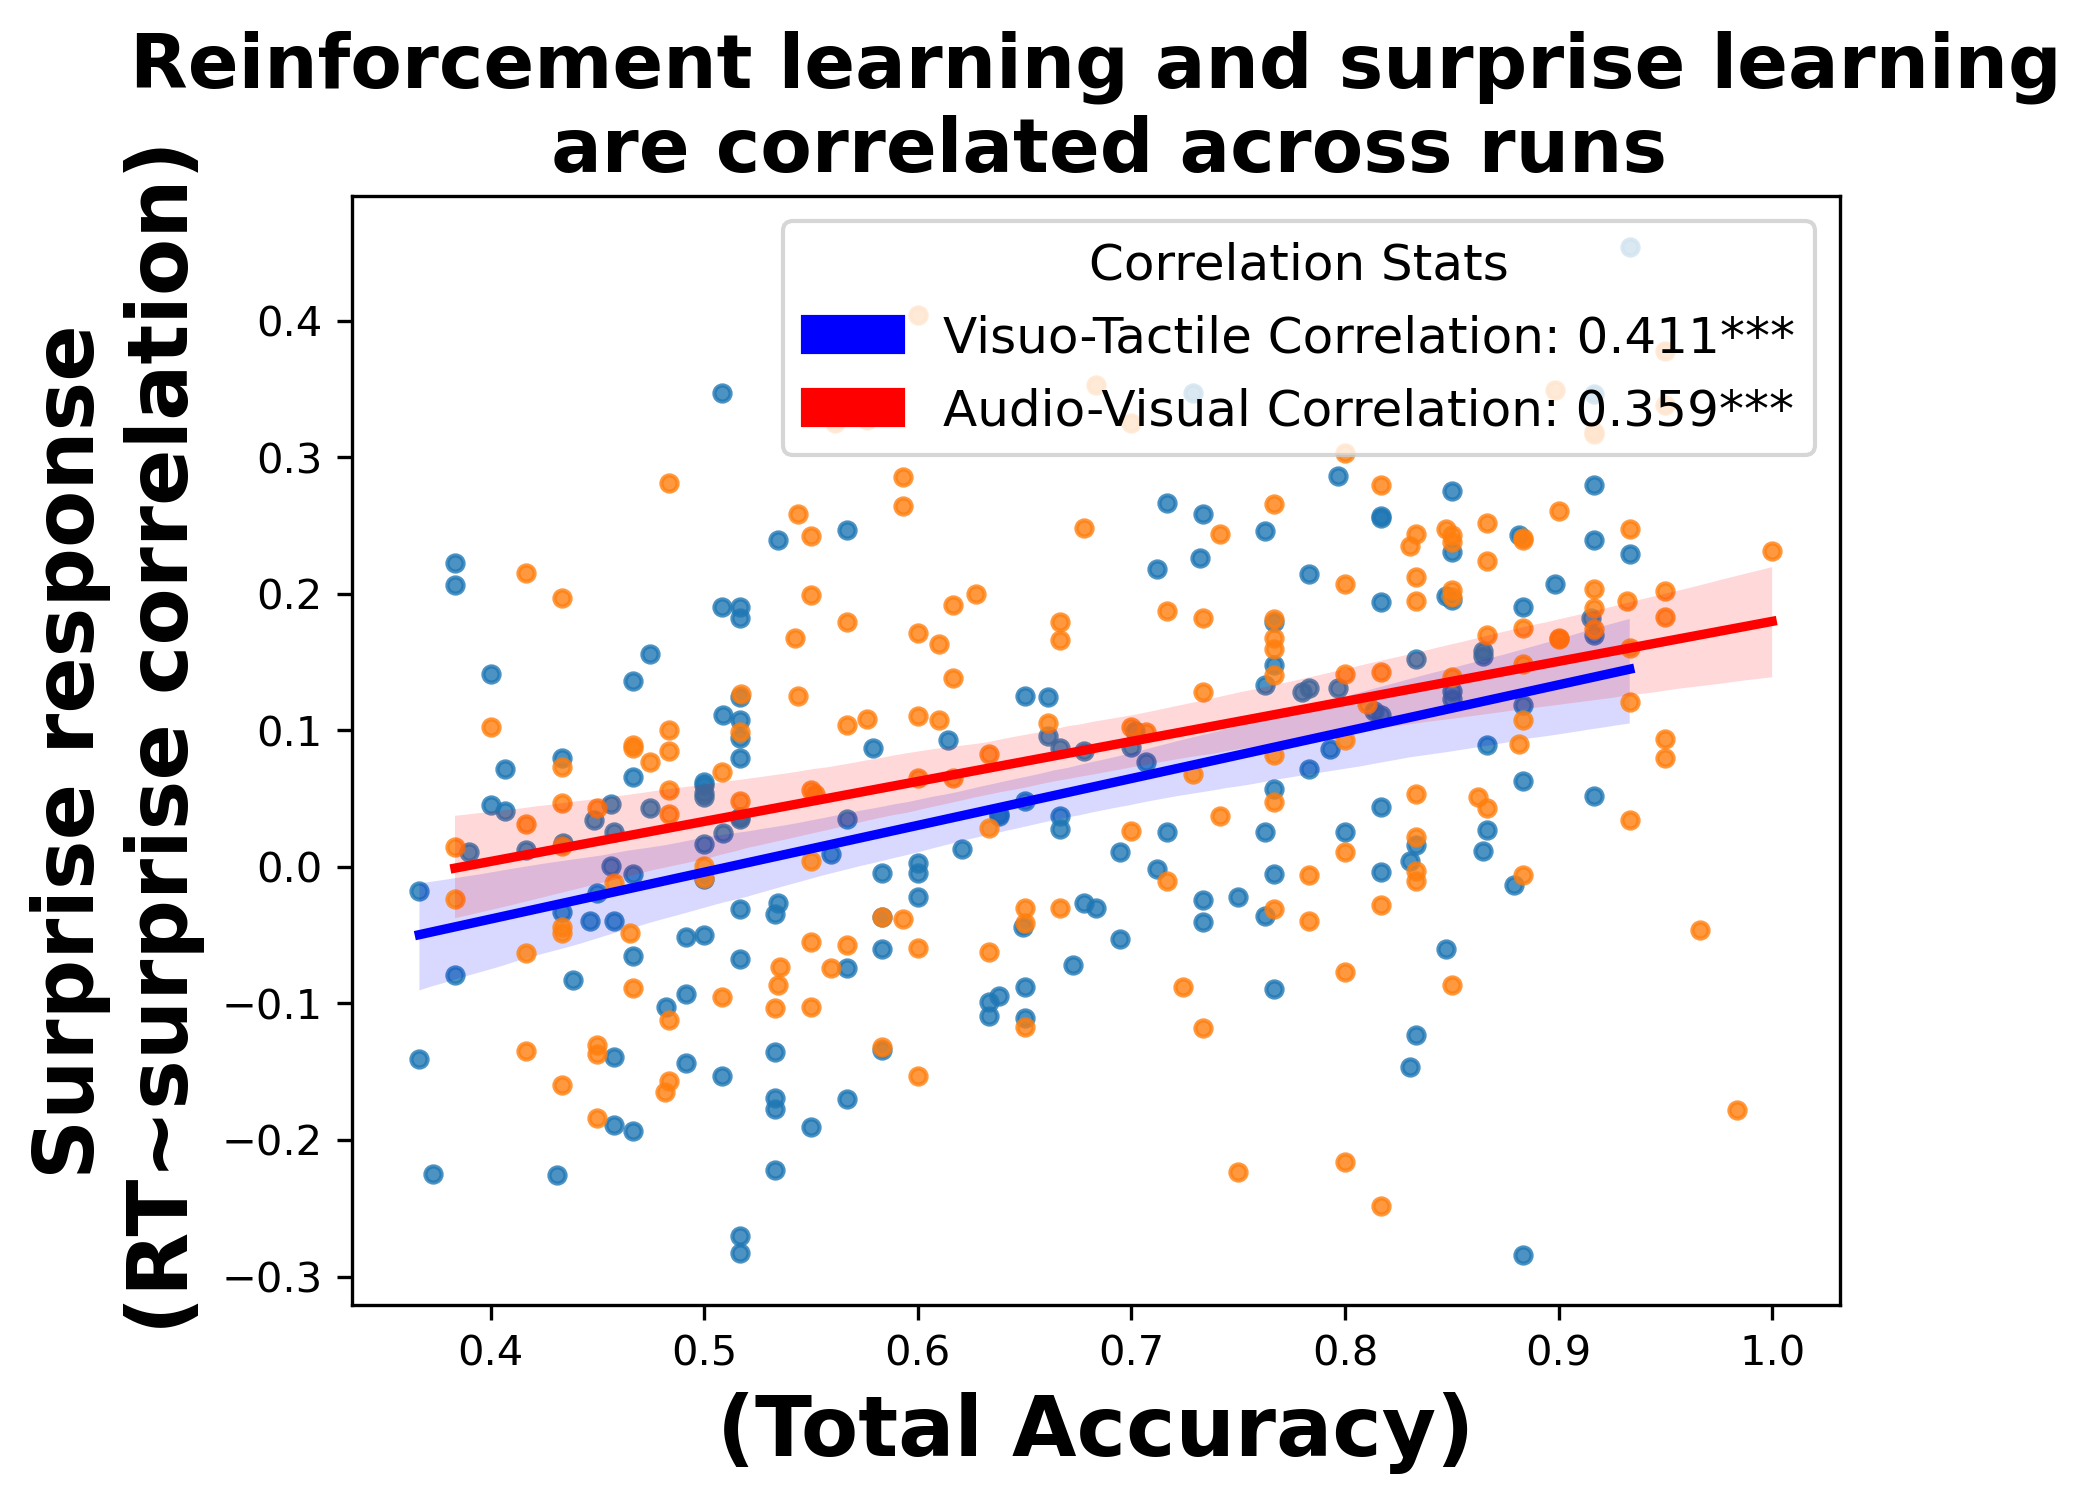

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib.patches as mpatches

# Set a high DPI for high-quality images
plt.rcParams['figure.dpi'] = 300

# Create separate dataframes for audio_indicator 0 and 1
df_audio_0 = runWiseDF[runWiseDF['audio_indicator'] == 0]
df_audio_1 = runWiseDF[runWiseDF['audio_indicator'] == 1]

# Create a scatterplot with regression line for audio_indicator = 0 (blue)
sns.regplot(data=df_audio_0, x='lastTotalAccuracy', y='surpriseEffect', line_kws={"color": "blue"}, scatter_kws={"s": 15})

# Create a scatterplot with regression line for audio_indicator = 1 (red)
sns.regplot(data=df_audio_1, x='lastTotalAccuracy', y='surpriseEffect', line_kws={"color": "red"}, scatter_kws={"s": 15})

# Calculate the correlation and p-value for audio_indicator = 0
correlation_tactile, p_value_tactile = stats.pearsonr(df_audio_0['lastTotalAccuracy'], df_audio_0['surpriseEffect'])

# Calculate the correlation and p-value for audio_indicator = 1
correlation_audio, p_value_audio = stats.pearsonr(df_audio_1['lastTotalAccuracy'], df_audio_1['surpriseEffect'])

# Set plot labels
plt.xlabel('(Total Accuracy)', fontsize=20, weight='bold')
plt.ylabel('Surprise response\n (RT~surprise correlation)', fontsize=20, weight='bold')

# Create custom legend
legend_labels = [
    mpatches.Patch(color='blue', label=f'Visuo-Tactile Correlation: {correlation_tactile:.3f}***'),
    mpatches.Patch(color='red', label=f'Audio-Visual Correlation: {correlation_audio:.3f}***'),
]

# Add legend with custom text labels and line colors
plt.legend(handles=legend_labels, loc='upper right', fontsize=12, title='Correlation Stats', title_fontsize=12)

# Set the title
plt.title('Reinforcement learning and surprise learning\n are correlated across runs', fontsize=18, weight='bold')

# Show the plot
plt.show()


In [33]:
p_value_audio

1.1856112996610981e-06

In [34]:
p_value_tactile

1.759012716858269e-08

In [ ]:
# Effect of spe on RT
data=df.dropna(subset=['responseTime'])

df.loc[:,"audio_indicator"] = df.loc[:,"audio_indicator"] - df.loc[:,"audio_indicator"].mean()

import statsmodels.formula.api as sm

# df = df.reset_index()

# Create the formula for the mixed-effects model
formula = 'responseTime ~ spe + audio_indicator + spe:audio_indicator'

# Fit the mixed-effects model using the MixedLM class
model = sm.mixedlm(formula, data=df.dropna(subset=['responseTime']).reset_index(), groups='subject', re_formula='~audio_indicator')

model_fit = model.fit(method='bfgs')

# Print the summary of the model
print(model_fit.summary())

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a white background for the entire figure
plt.rcParams['axes.facecolor'] = 'white'

# Set a high DPI for high-quality images
plt.rcParams['figure.dpi'] = 300

# Generate data for line plots
x0 = np.linspace(min(df[df['audio_indicator'] == -0.5]['spe']), max(df[df['audio_indicator'] == -0.5]['spe']), 100)
y0 = model_fit.params['spe'] * x0 + model_fit.params['Intercept']
ci0 = model_fit.conf_int().loc['spe']
y0_upper = ci0[1] * x0 + model_fit.params['Intercept']
y0_lower = ci0[0] * x0 + model_fit.params['Intercept']

x1 = np.linspace(min(df[df['audio_indicator'] == 0.5]['spe']), max(df[df['audio_indicator'] == 0.5]['spe']), 100)
y1 = (model_fit.params['spe'] * x1 + model_fit.params['audio_indicator']
      + model_fit.params['spe:audio_indicator'] + model_fit.params['Intercept'])
ci1 = model_fit.conf_int().loc[['spe', 'audio_indicator', 'spe:audio_indicator']]
y1_upper = (ci1.loc['spe', 1] * x1 + ci1.loc['audio_indicator', 1]
            + ci1.loc['spe:audio_indicator', 1] + model_fit.params['Intercept'])
y1_lower = (ci1.loc['spe', 0] * x1 + ci1.loc['audio_indicator', 0]
            + ci1.loc['spe:audio_indicator', 0] + model_fit.params['Intercept'])

# Create figure and axis objects
fig, ax = plt.subplots()

# Plot lines and confidence intervals for correlations between spe and responseTime
ax.plot(x0, y0, color='blue', alpha=1., linewidth=2, label='tactile runs')
ax.fill_between(x0, y0_upper, y0_lower, color='blue', alpha=.1)
ax.plot(x1, y1, color='red', alpha=1., linewidth=2, label='audio runs')
ax.fill_between(x1, y1_upper, y1_lower, color='red', alpha=.1)

# Overlay scatter plots for two audio_indicator values (uncomment if needed)
# ax.scatter(df[df['audio_indicator'] == 0]['spe'], df[df['audio_indicator'] == 0]['responseTime'], color='blue', alpha=0.04, s=1)
# ax.scatter(df[df['audio_indicator'] == 1]['spe'], df[df['audio_indicator'] == 1]['responseTime'], color='red', alpha=0.04, s=1)

# Set axis labels and legend
ax.set_xlabel('Surprise', fontsize=28, weight='bold')
ax.set_ylabel('Response Time', fontsize=28, weight='bold')
plt.title("RT increases with surprise\nFaster RT for audio-visual", fontsize=28, weight='bold')
ax.legend()

# Remove grid lines
ax.grid(False)

# Show only axis lines and axis ticks
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Save the figure with a white background
plt.savefig("publication_worthy_figure.png", dpi=300, bbox_inches="tight")

# Show plot
plt.show()


In [7]:
# With trialwise

In [42]:

# Create an empty DataFrame to store the results
result_df = pd.DataFrame()

for subject in subjects:
    alpha_dir = f'/Volumes/SDrive/multlearn-sns/Modelling/Fitting/bestFittingVals/sub-{subject:02d}'

    # Find all files that start with "alphas" in the subject directory
    alpha1_files = [os.path.join(root, name) for root, dirs, files in os.walk(alpha_dir) for name in files if name.startswith("alphasPos")]
    alpha2_files = [os.path.join(root, name) for root, dirs, files in os.walk(alpha_dir) for name in files if name.startswith("alphas2Pos")]


    # Loop through the alpha_files and read them into DataFrames
    for alpha_file in alpha_files:
        alpha1 = pd.read_csv(alpha_file, delimiter='\t', header=None)  # Assuming it's a TSV file



In [44]:
subjects

[1, 2, 3]